# Build a basic chatbot with Langraph (Graph API)

    Components of LangGraph
    1. Edges
    2. Nodes
    3. State
    
    2 ways to create
    Graph API and Functional API in langgraph
    
    

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    """
        Messages have the type list, the 'add_messages' function
        in the annotation defines how this state key should be updated
        in this case it appends messages to the list, rather than overwritting them.
        
        e.g. class Point2D(TypedDict):
                x: int
                y: int
                label: str

            a: Point2D = {'x': 1, 'y': 2, 'label': 'good'}  # OK
            b: Point2D = {'z': 3, 'label': 'bad'}           # Fails type check
    """
    messages: Annotated[list, add_messages]
    # Annotated is just a kind of a label 
    # here add_messages is kind of a REDUCER which simply means it is not going to replace the list and only append the 
    # messages to that list
    
    
graph_builder = StateGraph(State)
# it will simply provide the info to different different nodes
    

In [3]:
graph_builder

In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [6]:
# os.environ["GROQ_API_KEY"]

In [7]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028D15114D70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028D15115A90>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
llm = init_chat_model("groq:openai/gpt-oss-20b")  # in this you only need to mention the model company name eg. openai: , or groq:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028D151C9F90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028D151CA990>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [9]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [10]:
graph_builder = StateGraph(State)

# adding nodes
graph_builder.add_node("llmchatbot", chatbot)

# adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compile the graph
graph = graph_builder.compile()


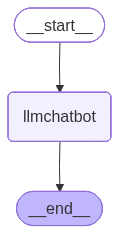

In [11]:
# visulie the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

In [12]:
response = graph.invoke({"messages": "Hi"})
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='e0cf4701-b44b-4d3b-8fd6-fd5fc9611051'),
  AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Hi". Probably need to respond politely, ask how can help.'}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 72, 'total_tokens': 109, 'completion_time': 0.038189408, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.003464654, 'prompt_tokens_details': None, 'queue_time': 0.281166896, 'total_time': 0.041654062}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d23c14756c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eea65-521b-7270-af03-505ba5ac19a6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 37, 'total_tokens': 109, 'output_token_details': {'reasoning': 17}})]}

In [13]:
response["messages"][-1].content

'Hello! 👋 How can I help you today?'

## Streaming

In [14]:
for event in graph.stream({"messages": "Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)
        

Hello! I'm doing great, thanks for asking. How can I help you today?


In [15]:
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# Chatbot with Tool

In [16]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is Langraph?")

{'query': 'What is Langraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. The core concepts of LangGraph include: graph structure, state management, and coordination. In LangGraph, each node represents

In [77]:
## Custom function
def multiply(a:int, b:int)->int:
    """Multiply a and b
    
    
    Args:
        a (int): first int
        b (int): second int
    Returns:
        int: output int
        
    """
    return a*b
    

In [78]:
tools = [tool, multiply]

In [79]:
tools

[TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)),
 <function __main__.multiply(a: int, b: int) -> int>]

In [80]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028D151C9F90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028D151CA990>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [81]:
tools

[TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)),
 <function __main__.multiply(a: int, b: int) -> int>]

### Bind the llm with tools

In [82]:
llm_with_tool = llm.bind_tools(tools)

In [83]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028D151C9F90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028D151CA990>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers 

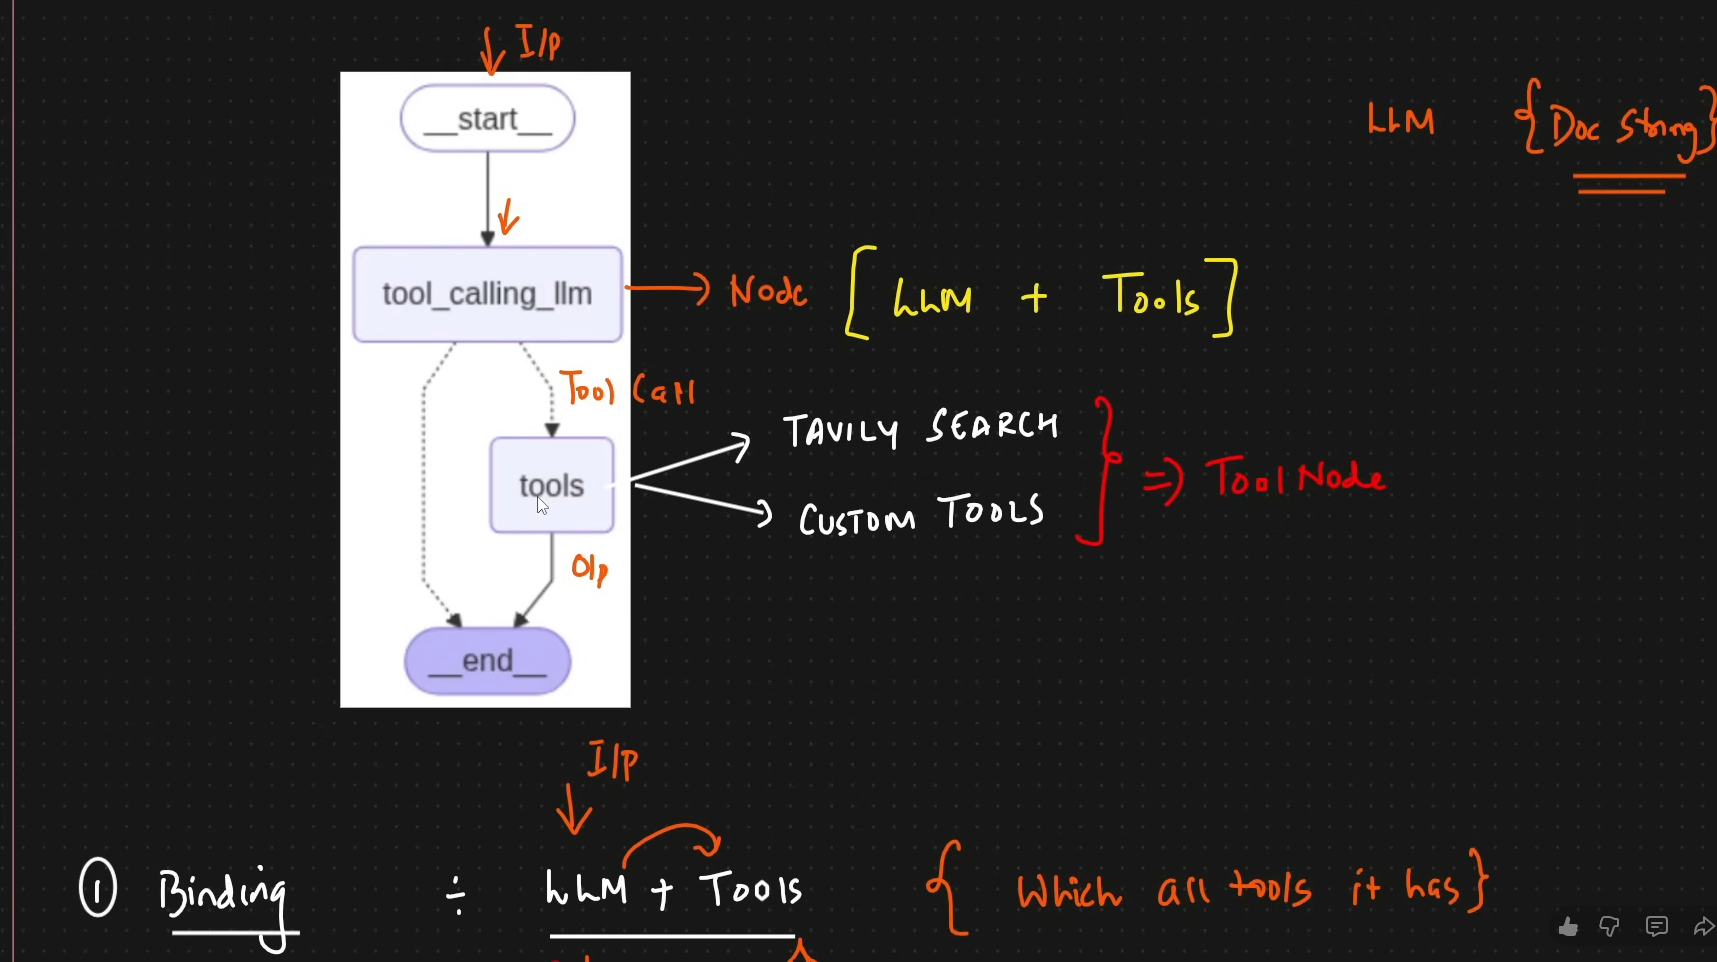

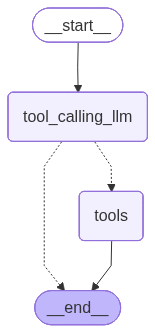

In [84]:
#### Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))  # this node is the tools block in the diagram

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges( 
    "tool_calling_llm", 
    # If the latest message (result) from assistant is a tool call -> tool_condition routes to tools
    # If the latest message (result) from assistant is NOT a tool call -> tool_condition routes to END
    tools_condition
)

builder.add_edge("tools", END)

# compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))




In [52]:
response = graph.invoke({"messages": "What is the recent ai news?"})
response

{'messages': [HumanMessage(content='What is the recent ai news?', additional_kwargs={}, response_metadata={}, id='679d2aa0-c100-4837-85b9-f3dd18f4e1a6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the recent ai news?" They want recent AI news. We need to browse for current events. We should use tavily_search with query "recent AI news" and maybe time range "day" or "week". Let\'s do a search.', 'tool_calls': [{'id': 'fc_a4f52235-8ae2-45b7-b9c4-441fbe328871', 'function': {'arguments': '{"query":"recent AI news","search_depth":"basic","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 372, 'total_tokens': 469, 'completion_time': 0.123223372, 'completion_tokens_details': {'reasoning_tokens': 56}, 'prompt_time': 0.018070167, 'prompt_tokens_details': None, 'queue_time': 0.313221053, 'total_time': 0.141293539}, 'model_name': 'openai/gpt

In [59]:
response.get("messages")[-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/208209-nobel-laureate-john-jumper-moves-from-google-deepmind-to-anthropic.html", "title": "Nobel Laureate John Jumper Moves from Google DeepMind to Anthropic - Zamin.uz", "score": 0.67347145, "published_date": "Sat, 20 Jun 2026 16:58:51 GMT", "content": "# Nobel Laureate John Jumper Moves from Google DeepMind to Anthropic. An unexpected transfer has occurred in the world of AI: renowned scientist John Jumper, a recent Nobel Prize winner in Chemistry, has left the DeepMind laboratory within Google. Considered one of the most prestigious experts in the field, Jumper will continue his career at Anthropic, one of Google\'s primary competitors. John Jumper and Demis Hassabis were awarded the Nobel Prize in 2024 for creating the AlphaFold AI model, which can predict the 3D structure of proteins based on genetic sequences. Previously, it was revealed that

In [60]:
for m in response.get("messages"):
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_a4f52235-8ae2-45b7-b9c4-441fbe328871)
 Call ID: fc_a4f52235-8ae2-45b7-b9c4-441fbe328871
  Args:
    query: recent AI news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/208209-nobel-laureate-john-jumper-moves-from-google-deepmind-to-anthropic.html", "title": "Nobel Laureate John Jumper Moves from Google DeepMind to Anthropic - Zamin.uz", "score": 0.67347145, "published_date": "Sat, 20 Jun 2026 16:58:51 GMT", "content": "# Nobel Laureate John Jumper Moves from Google DeepMind to Anthropic. An unexpected transfer has oc

In [85]:
response = graph.invoke({"messages": "What is 2 multiplied by 3"})
response

{'messages': [HumanMessage(content='What is 2 multiplied by 3', additional_kwargs={}, response_metadata={}, id='73359188-84e6-49b8-9251-3b369e9496aa'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is 2 multiplied by 3". This is a simple multiplication. According to tool, we can use the multiply function. We should call it.', 'tool_calls': [{'id': 'fc_f1d44660-58f6-48dc-9fb6-34f2439d6c35', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 373, 'total_tokens': 435, 'completion_time': 0.068949036, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.020798423, 'prompt_tokens_details': None, 'queue_time': 0.301263047, 'total_time': 0.089747459}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e11c8bbf69', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, 

In [86]:
for m in response.get("messages"):
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_f1d44660-58f6-48dc-9fb6-34f2439d6c35)
 Call ID: fc_f1d44660-58f6-48dc-9fb6-34f2439d6c35
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


# ReAct architecture

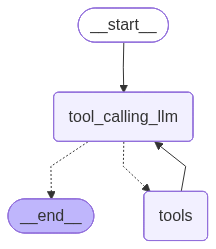

In [87]:
#### Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))  # this node is the tools block in the diagram

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges( 
    "tool_calling_llm", 
    # If the latest message (result) from assistant is a tool call -> tool_condition routes to tools
    # If the latest message (result) from assistant is NOT a tool call -> tool_condition routes to END
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

# compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


